This notebook provides a graphical analysis of all the aggregated data (INFO284 + IGSIN919 + INF266) collected during the survey.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data loading

In [2]:
df = pd.read_csv('data.csv', encoding='latin-1')
df.head()

,Group,"1. On average, how many hours per week do you use AI tools for this course?\n",2. Which AI tools do you regularly use for this course? - ChatGPT,2. Which AI tools do you regularly use for this course? - Gemini,2. Which AI tools do you regularly use for this course? - Claude,2. Which AI tools do you regularly use for this course? - Copilot,2. Which AI tools do you regularly use for this course? - DeepSeek,2. Which AI tools do you regularly use for this course? - Grok,2. Which AI tools do you regularly use for this course? - Other (specify),2. Which AI tools do you regularly use for this course? - Other (specify).1,...,8. How do you think of an AI tool while interacting with it? - A text or code generator,8. How do you think of an AI tool while interacting with it? - A knowledge interface,8. How do you think of an AI tool while interacting with it? - Other (specify),8. How do you think of an AI tool while interacting with it? - Other (specify).1,"Thank you for participating in the survey! If you have any comments regarding the survey, you can leave them here.",Overall Status - New,Overall Status - Distributed,Overall Status - Partially Complete,Overall Status - Complete,Overall Status - Rejected
0,INFO284,More than 6,1,0,0,1,0,0,1,Github copilot,...,0,1,0,NaN,NaN,0,0,0,1,0
1,INFO284,1-2,1,0,1,1,0,0,0,NaN,...,1,0,0,NaN,NaN,0,0,0,1,0
2,INFO284,2-4,1,0,0,0,0,0,0,NaN,...,0,0,0,NaN,NaN,0,0,0,1,0
3,INFO284,2-4,1,0,1,0,0,0,0,NaN,...,0,0,0,NaN,NaN,0,0,0,1,0
4,INFO284,4-6,1,0,1,0,0,0,0,NaN,...,1,0,0,NaN,NaN,0,0,0,1,0


### Question 1

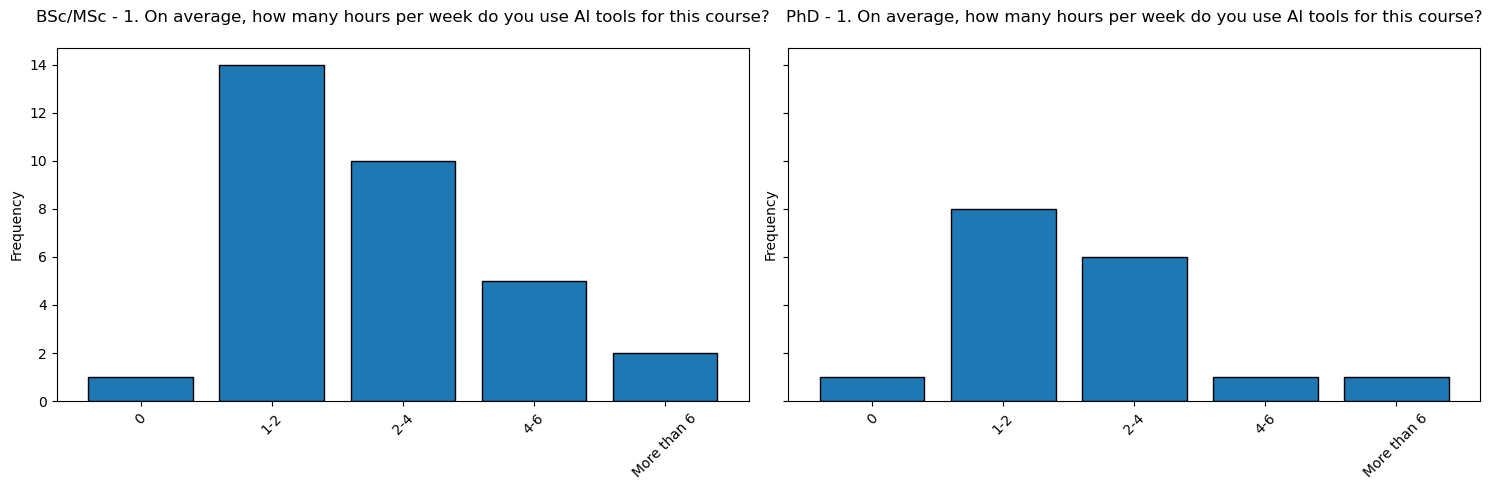

In [12]:
custom_order = ['0', '1-2', '2-4', '4-6', 'More than 6']  # replace with your actual categories
phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    
    # Count occurrences, then reindex to your order
    counts = filtered.iloc[:, 1].value_counts()
    counts = counts.reindex(custom_order)

    # Plot
    ax.bar(counts.index, counts.values, edgecolor='black')  # fix: ax.bar not ax.plot
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{phdlabels[i]} - {df.iloc[:, 1].name}')
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

### Question 2

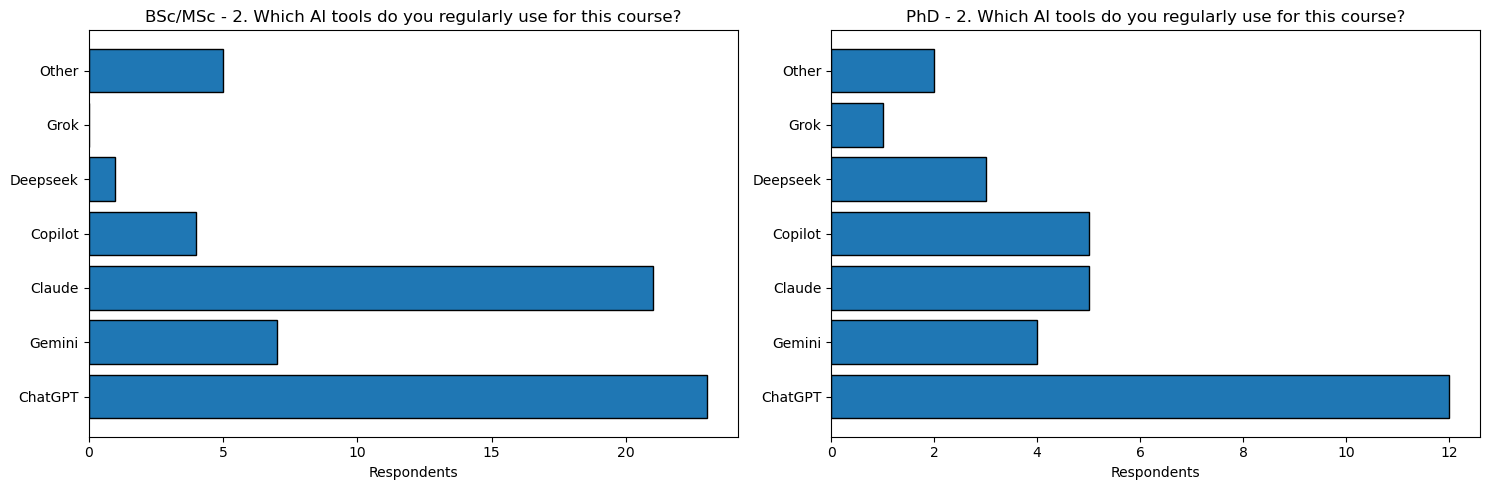

In [16]:
labels = ['ChatGPT', 'Gemini', 'Claude', 'Copilot', 'Deepseek', 'Grok', 'Other']
phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    sums = [filtered.iloc[:, i].sum() for i in np.arange(2,9)]
    
    # Plot
    ax.barh(labels, sums, edgecolor='black')
    ax.set_xlabel('Respondents')
    ax.set_title(f'{phdlabels[i]} - 2. Which AI tools do you regularly use for this course?')
    
plt.tight_layout()
plt.show()

### Question 3

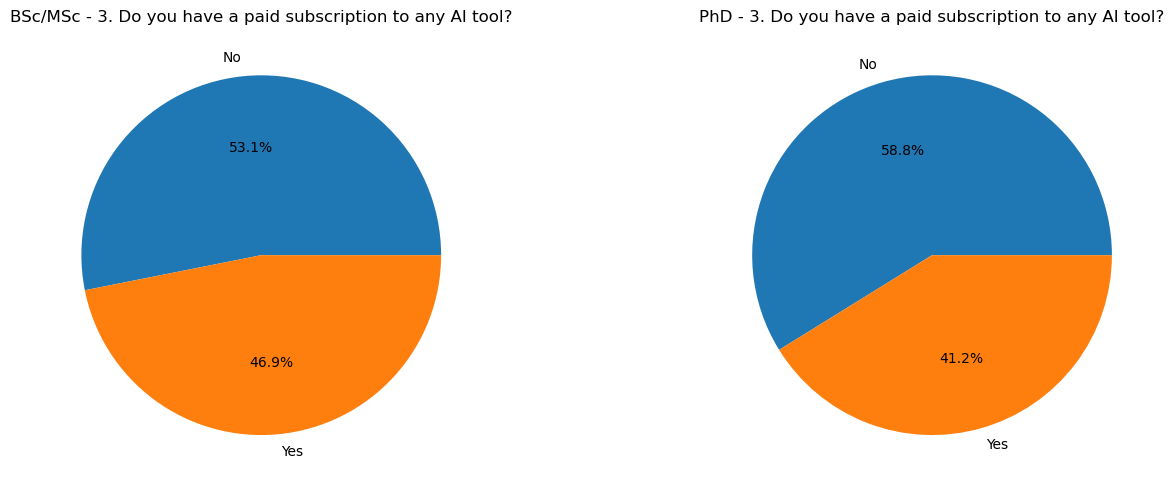

In [21]:
col10 = df.iloc[:, 10]

phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    
    # Plot
    counts = filtered.iloc[:, 10].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
    ax.set_title(f'{phdlabels[i]} - {col10.name}')
    
plt.tight_layout()
plt.show()


### Question 4

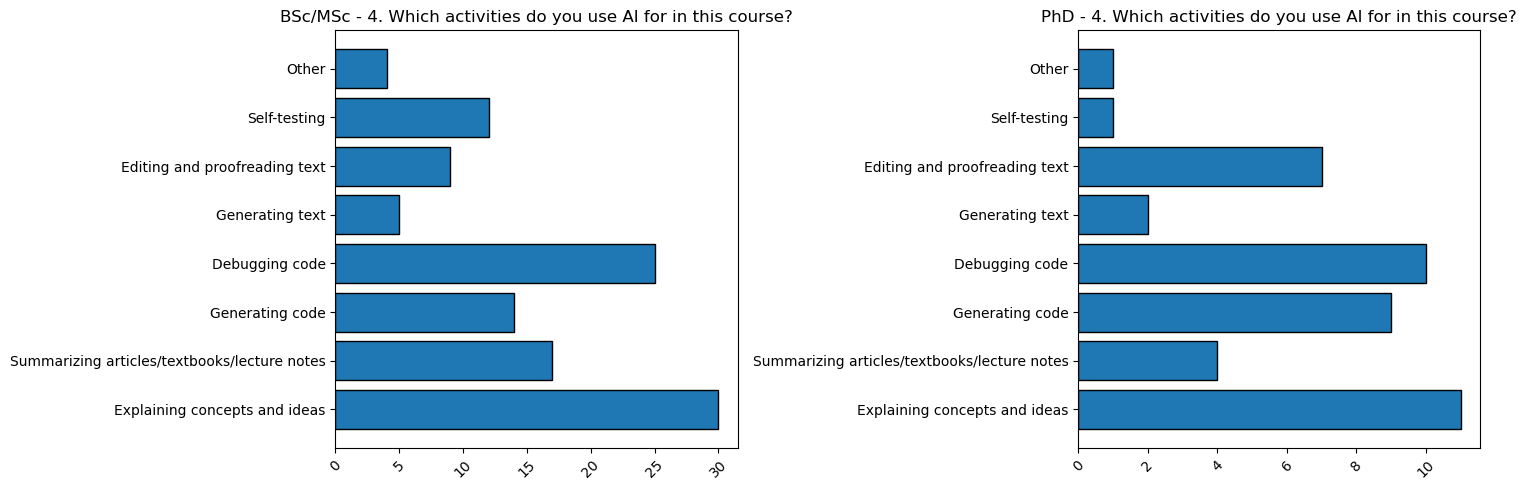

In [23]:
labels = ['Explaining concepts and ideas',
          'Summarizing articles/textbooks/lecture notes',
          'Generating code', 
          'Debugging code',
          'Generating text',
          'Editing and proofreading text',
          'Self-testing',
          'Other']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    sums = [filtered.iloc[:, i].sum() for i in np.arange(11,19)]
    ax.barh(labels, sums, edgecolor='black')
    ax.set_title(f'{phdlabels[i]} - 4. Which activities do you use AI for in this course?')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Question 5

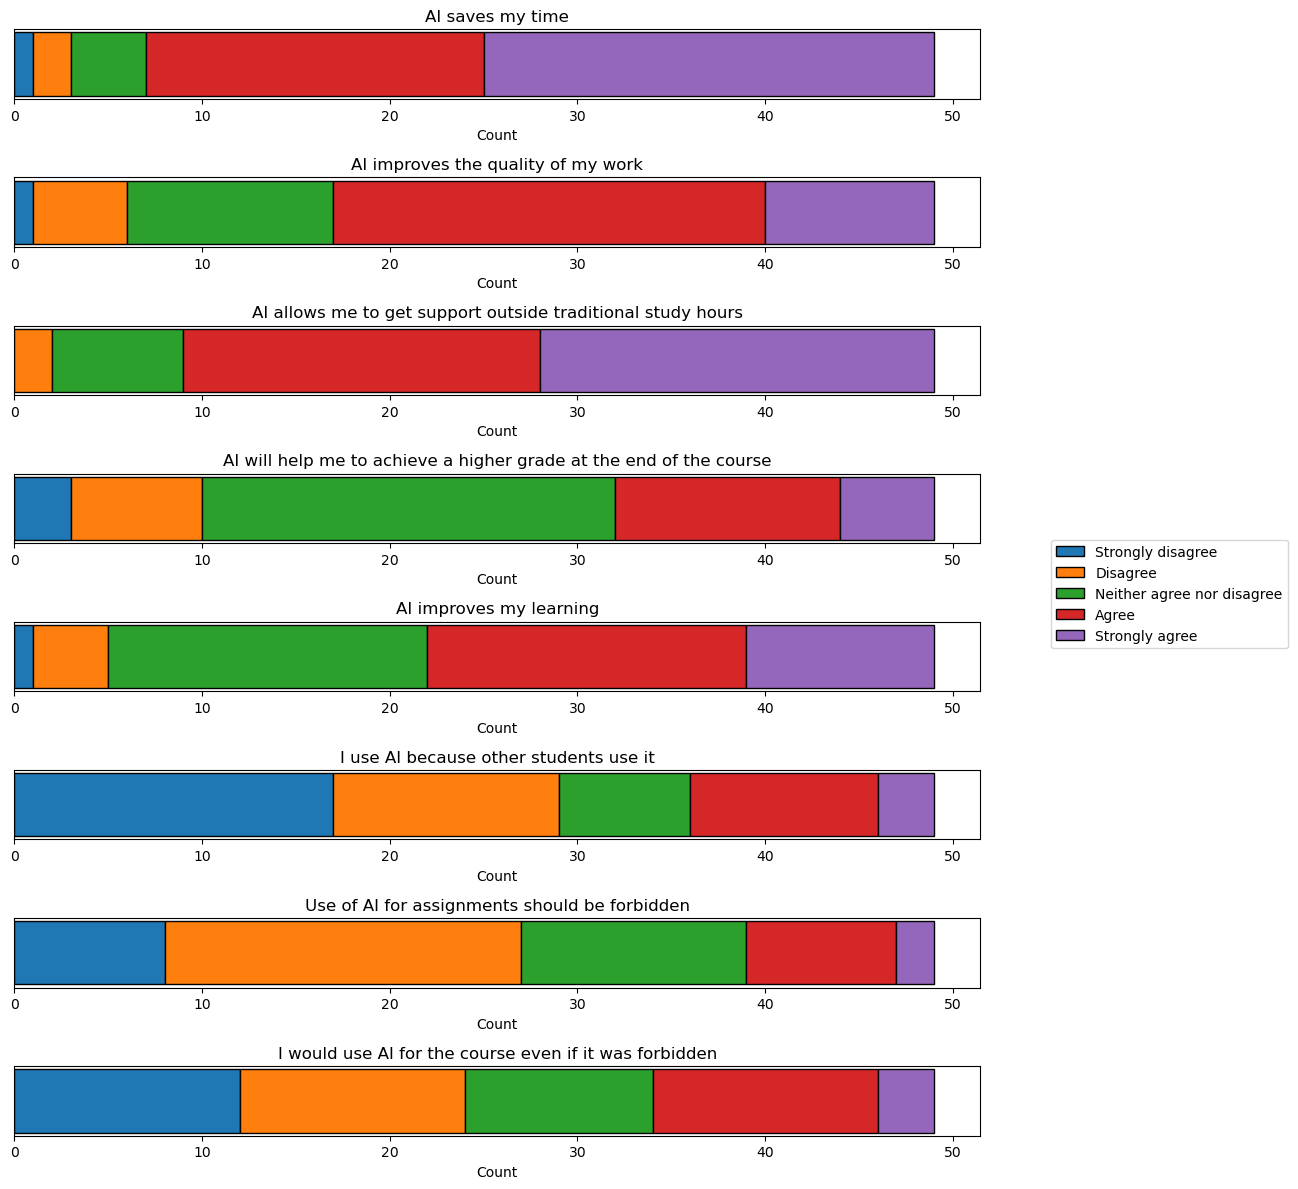

In [8]:
cols = [df.iloc[:, i] for i in range(20,28)]
labels = ['AI saves my time',
          'AI improves the quality of my work', 
          'AI allows me to get support outside traditional study hours',
          'AI will help me to achieve a higher grade at the end of the course',
         'AI improves my learning',
         'I use AI because other students use it',
         'Use of AI for assignments should be forbidden',
         'I would use AI for the course even if it was forbidden']

fig, axes = plt.subplots(8, 1, figsize=(10, 12))

for ax, col, i in zip(axes, cols, range(len(labels))):
    counts = col.value_counts().reindex(['Strongly disagree', 'Disagree', 'Neither agree nor disagree', 'Agree', 'Strongly agree'], fill_value=0)
    left = 0
    for category, value in counts.items():
        ax.barh(0, value, left=left, label=category, edgecolor='black')
        left += value
    ax.set_yticks([])
    ax.set_xlabel('Count')
    #ax.set_ylabel(labels[i],rotation=0)
    ax.set_title(labels[i])
    #ax.legend(loc='upper right', bbox_to_anchor=(1, 1.5))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

### Question 6

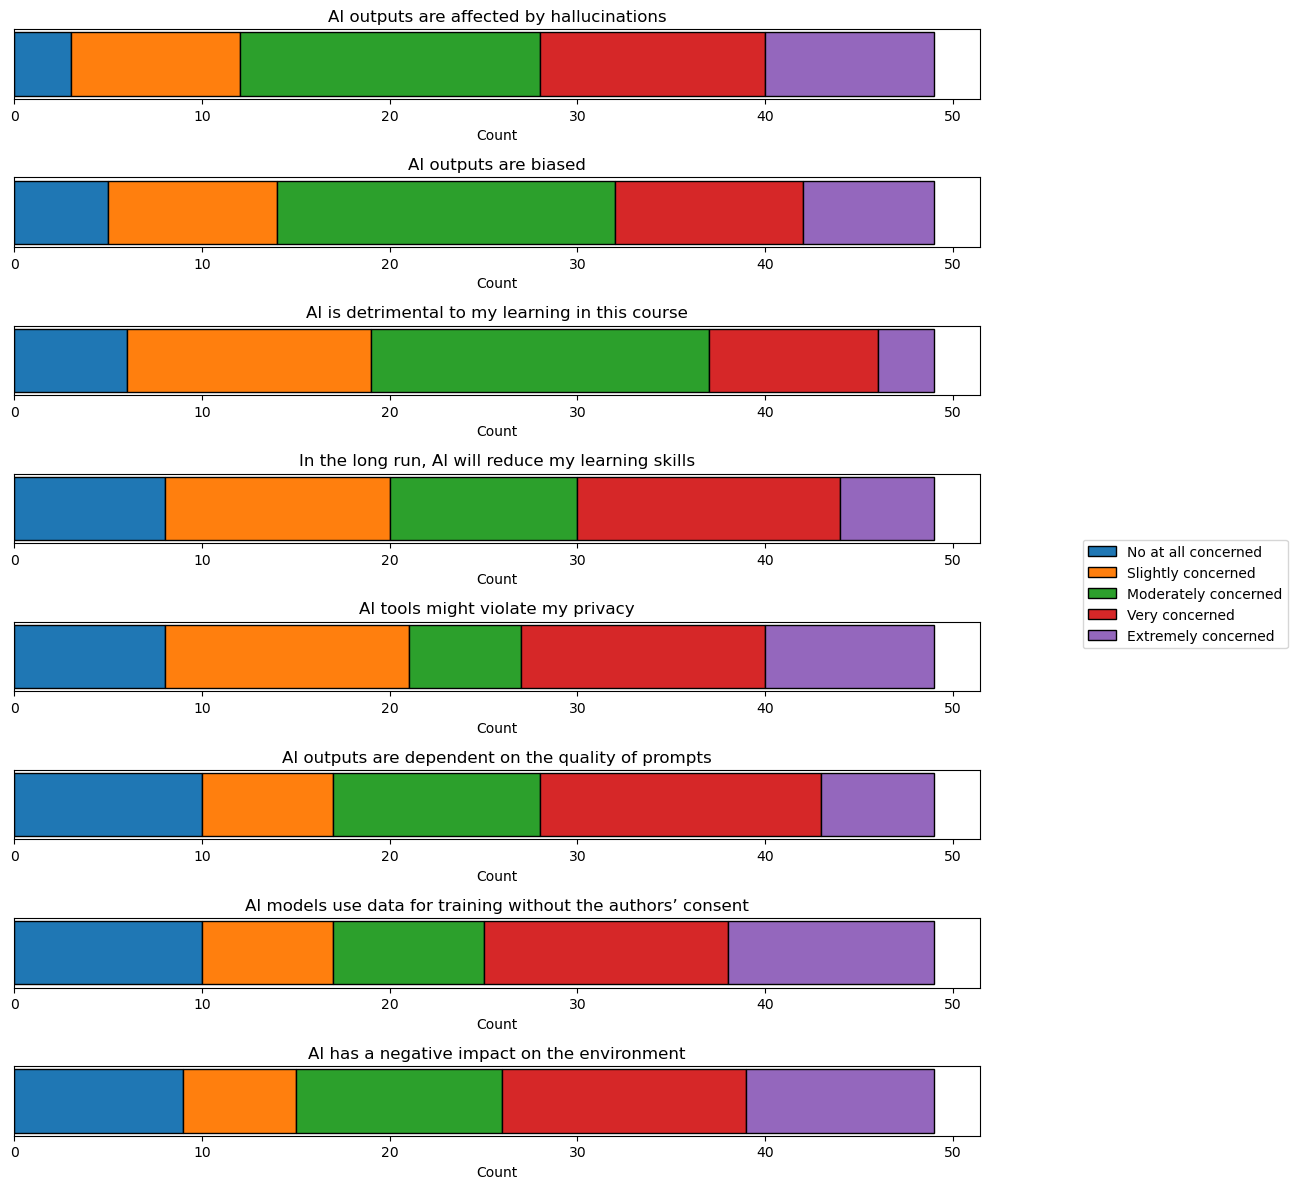

In [9]:
cols = [df.iloc[:, i] for i in range(28,36)]
labels = ['AI outputs are affected by hallucinations',
          'AI outputs are biased', 
          'AI is detrimental to my learning in this course',
          'In the long run, AI will reduce my learning skills',
         'AI tools might violate my privacy',
         'AI outputs are dependent on the quality of prompts',
         'AI models use data for training without the authors’ consent',
         'AI has a negative impact on the environment']

fig, axes = plt.subplots(8, 1, figsize=(10, 12))

for ax, col, i in zip(axes, cols, range(len(labels))):
    counts = col.value_counts().reindex(['No at all concerned', 'Slightly concerned', 'Moderately concerned', 'Very concerned', 'Extremely concerned'], fill_value=0)
    left = 0
    for category, value in counts.items():
        ax.barh(0, value, left=left, label=category, edgecolor='black')
        left += value
    ax.set_yticks([])
    ax.set_xlabel('Count')
    #ax.set_ylabel(labels[i],rotation=0)
    ax.set_title(labels[i])
    #ax.legend(loc='upper right', bbox_to_anchor=(1, 1.5))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

### Question 7

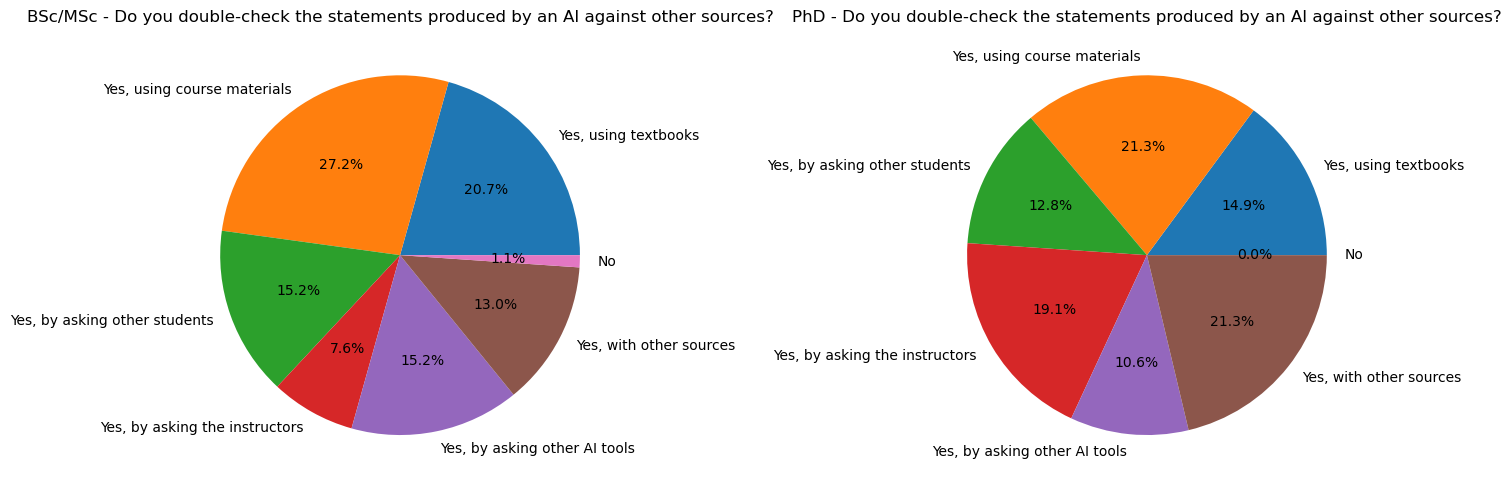

In [27]:
col10 = df.iloc[:, 36:43]
labels = ['Yes, using textbooks',
         'Yes, using course materials',
         'Yes, by asking other students',
         'Yes, by asking the instructors',
         'Yes, by asking other AI tools',
         'Yes, with other sources',
         'No']

phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = col10[df.iloc[:, 0].str.contains(val)]
    
    # Plot
    sums = filtered.sum()    
    ax.pie(sums.values, labels=labels, autopct='%1.1f%%')
    ax.set_ylabel('')  # hides the default y-label
    ax.set_title(f'{phdlabels[i]} - Do you double-check the statements produced by an AI against other sources?')
    
plt.tight_layout()
plt.show()



### Question 8

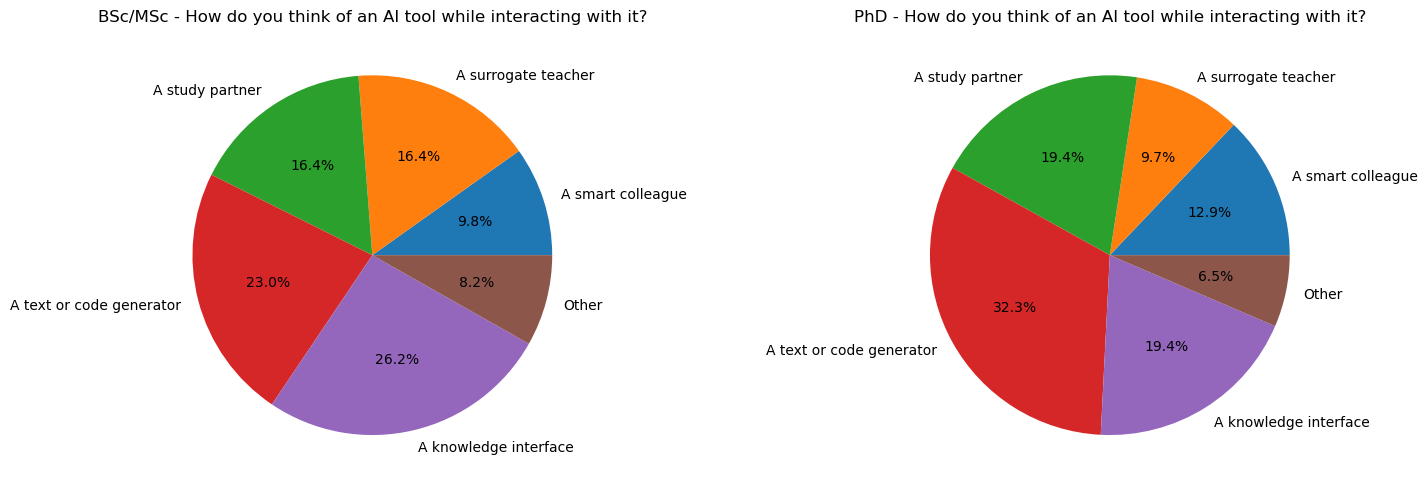

In [28]:
col10 = df.iloc[:, 44:50]
labels = ['A smart colleague',
         'A surrogate teacher',
         'A study partner',
         'A text or code generator',
         'A knowledge interface',
         'Other']

phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = col10[df.iloc[:, 0].str.contains(val)]
    
    # Plot
    sums = filtered.sum()    
    ax.pie(sums.values, labels=labels, autopct='%1.1f%%')
    ax.set_ylabel('')  # hides the default y-label
    ax.set_title(f'{phdlabels[i]} - How do you think of an AI tool while interacting with it?')

plt.tight_layout()
plt.show()